# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [3]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly as py 

# 1. Business Understanding
Goal: To predict resale price.

# 2. Data Understanding

## 2.1 Load dataset

In [4]:
## read *.csv file
FILE_PATH = "ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv"
df = pd.read_csv(FILE_PATH)

## filter to a smaller dataset do at top so below are all this
towns_to_keep = ['PUNGGOL', 'SENGKANG', 'HOUGANG']
## drop all towns not in the list of towns to keep
df = df[df['town'].isin(towns_to_keep)].reset_index(drop=True)
df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,HOUGANG,2 ROOM,986A,BUANGKOK CRES,10 TO 12,47.0,Model A,2012,94 years 04 months,252000.0
1,2017-01,HOUGANG,3 ROOM,22,HOUGANG AVE 3,01 TO 03,73.0,New Generation,1978,60 years 04 months,260000.0
2,2017-01,HOUGANG,3 ROOM,644,HOUGANG AVE 8,01 TO 03,60.0,Improved,1987,69 years,268000.0
3,2017-01,HOUGANG,3 ROOM,24,HOUGANG AVE 3,01 TO 03,67.0,New Generation,1978,60 years 05 months,269000.0
4,2017-01,HOUGANG,3 ROOM,108,HOUGANG AVE 1,01 TO 03,67.0,New Generation,1984,66 years 03 months,270000.0
...,...,...,...,...,...,...,...,...,...,...,...
47859,2026-05,SENGKANG,EXECUTIVE,102,RIVERVALE WALK,16 TO 18,144.0,Apartment,1999,71 years 11 months,970000.0
47860,2026-05,SENGKANG,EXECUTIVE,102,RIVERVALE WALK,13 TO 15,141.0,Apartment,1999,71 years 10 months,930000.0
47861,2026-06,SENGKANG,EXECUTIVE,103,RIVERVALE WALK,04 TO 06,143.0,Maisonette,1999,71 years 10 months,886000.0
47862,2026-03,SENGKANG,EXECUTIVE,202B,SENGKANG EAST RD,13 TO 15,130.0,Apartment,2001,74 years 02 months,875000.0


## 2.2 Summary Statistics

In [5]:

## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47864 entries, 0 to 47863
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                47864 non-null  object 
 1   town                 47864 non-null  object 
 2   flat_type            47864 non-null  object 
 3   block                47864 non-null  object 
 4   street_name          47864 non-null  object 
 5   storey_range         47864 non-null  object 
 6   floor_area_sqm       47864 non-null  float64
 7   flat_model           47864 non-null  object 
 8   lease_commence_date  47864 non-null  int64  
 9   remaining_lease      47864 non-null  object 
 10  resale_price         47864 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 4.0+ MB


In [6]:
## Check for missing data
df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [7]:
## Describe data distribution
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,47864.000000,47864.000000,4.786400e+04
mean,97.777453,2006.612903,5.362435e+05
std,19.357725,10.588648,1.414658e+05
min,37.000000,1975.000000,1.950000e+05
25%,92.000000,2001.000000,4.300000e+05
50%,93.000000,2012.000000,5.200000e+05
75%,111.000000,2015.000000,6.280000e+05
max,177.000000,2022.000000,1.470000e+06


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

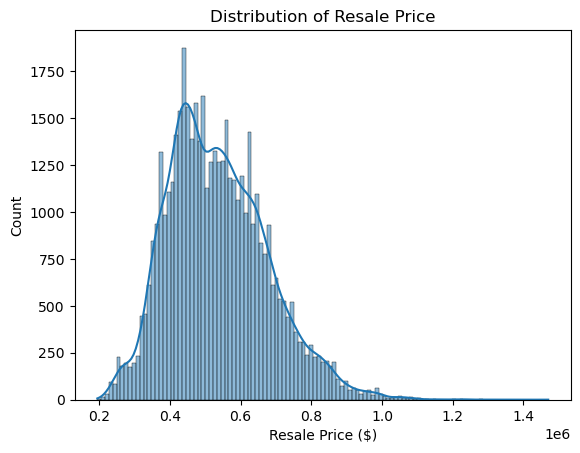

In [8]:
## Understanding distribution of target
# Target = resale_price. A histogram shows its shape (e.g. skew, common price range).
sns.histplot(df['resale_price'], kde=True)
plt.title('Distribution of Resale Price')
plt.xlabel('Resale Price ($)')
plt.ylabel('Count')
plt.show()

**Distribution of resale price (target)**

- Prices range **$195k to $1.47M**, with the mean **$536k** slightly above the median **$520k**, so the distribution is **mildly right-skewed** (skew ~ 0.59): a small number of expensive flats pull the average up.
- Only **0.9%** of flats (441 rows) fall outside the IQR outlier range, so there are **very few extreme outliers**.

**Implications for modelling:**
- The skew is mild, so tree-based models handle it well as-is; no log transform needed.
- With so few outliers, the mean is representative and **RMSE is approximately equal to MAE**, so both error metrics are reliable and no aggressive outlier removal is required.

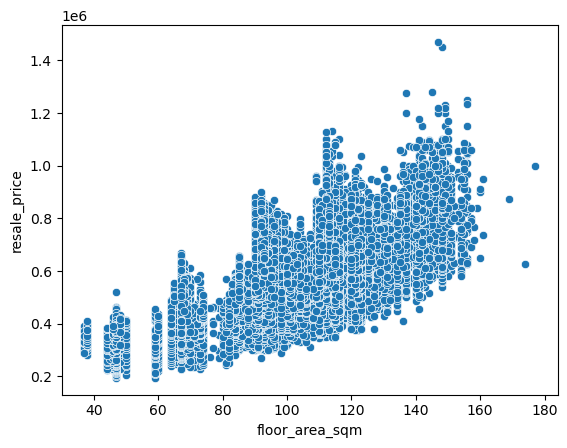

In [9]:
## Scatter plot of floor area vs resale price
scatter = sns.scatterplot(x='floor_area_sqm', y='resale_price', data=df)

### 2.3.1.2 Understanding distribution of features

<Figure size 640x480 with 0 Axes>

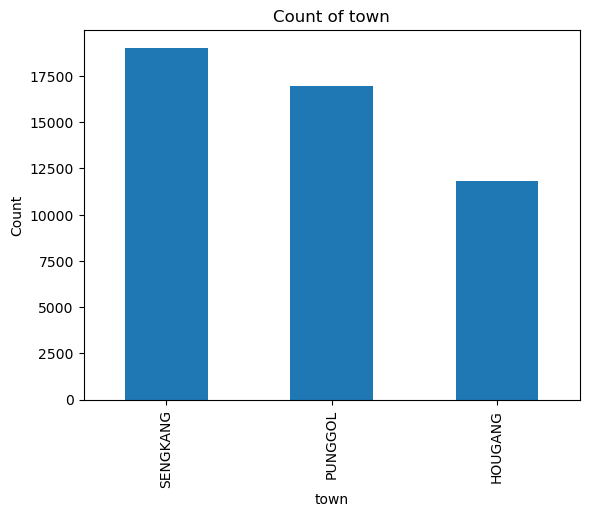

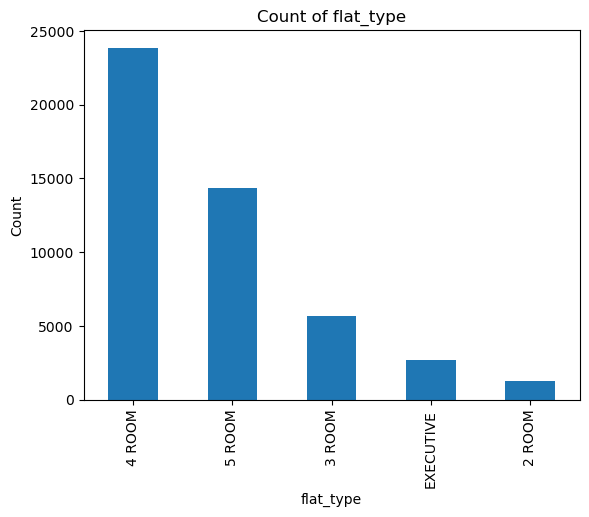

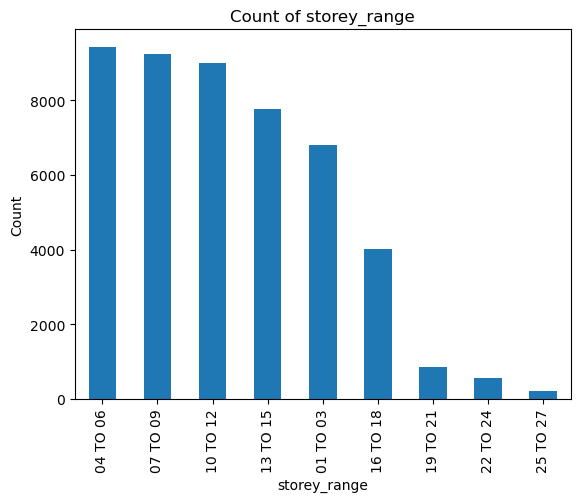

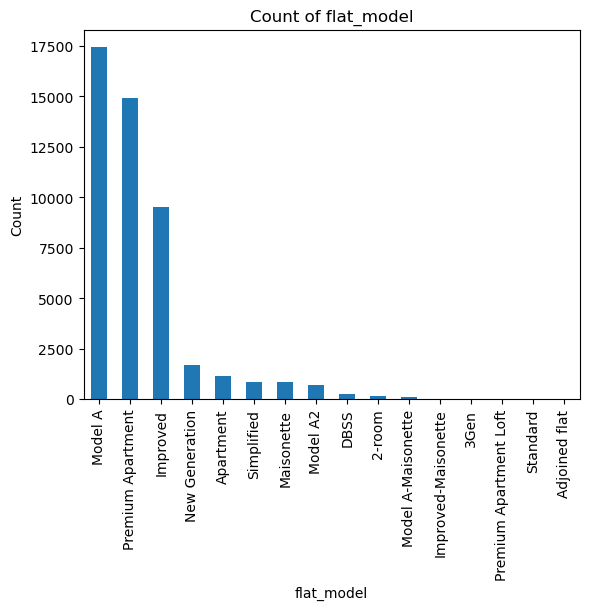

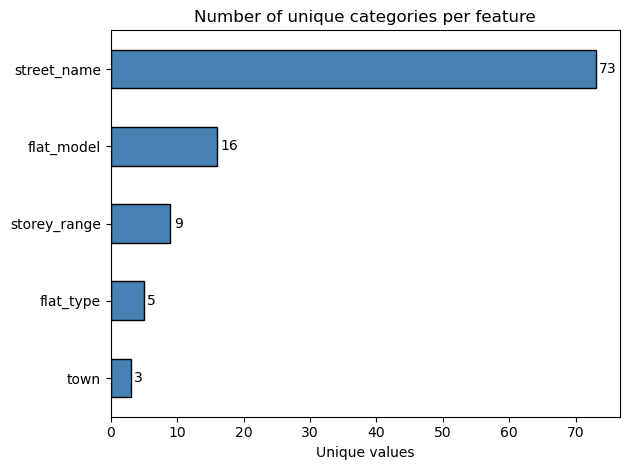

In [10]:
# numeric features: histogram of each
plt.tight_layout()
plt.show()

# categorical features: count of each category
categorical_cols = ['town', 'flat_type', 'storey_range', 'flat_model']
for col in categorical_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()
    
df['street_name'].nunique()
cat_cols = ['town', 'flat_type', 'storey_range', 'flat_model', 'street_name']
cardinality = df[cat_cols].nunique().sort_values()

ax = cardinality.plot(kind='barh', color='steelblue', edgecolor='black')
ax.set_title('Number of unique categories per feature')
ax.set_xlabel('Unique values')
for i, v in enumerate(cardinality):          # label each bar with its count
    ax.text(v + 0.5, i, str(v), va='center')
plt.tight_layout()
plt.show()


**Distribution of features**

- **Numeric features (`df.hist`):** `floor_area_sqm` clusters around common HDB
  sizes, and `lease_commence_date` leans toward newer flats.
- **Town** is fairly balanced across the three estates — Sengkang (19,037),
  Punggol (16,983), Hougang (11,844) — so no town dominates the sample.
- **Flat type is imbalanced:** 4-ROOM (23,861, ~50%) and 5-ROOM (14,340, ~30%)
  dominate, while 2-ROOM (1,258) and EXECUTIVE (2,702) are rare.
- **Storey range** concentrates in the low-to-mid floors (04–15 hold most sales)
  and tapers off for higher floors.
- **Flat model** has 16 categories but is dominated by a few — Model A (17,439),
  Premium Apartment (14,937), Improved (9,533); 6 of the 16 models have <100 rows
  and were grouped into "Other" during cleaning.

**Implications for modelling:**
- One-hot encoding suits the low-cardinality categoricals (town, flat_type).
- The flat-type and flat-model imbalance means overall test error is driven
  mostly by the common types (4/5-ROOM, Model A / Premium Apartment).
- Grouping rare flat models avoids near-empty one-hot columns that add noise
  without signal.
- street_name and flat_model have many categories, street_name 73 and flat_model 16 so one hot encoding would add many sparse columns.Need to tweak to either combine as others or drop in feature selection further down.


**Distribution of features**

- **Flat type is imbalanced:** 4-ROOM (23,861 rows, ~50%) and 5-ROOM (14,340,
  ~30%) dominate, while 2-ROOM (1,258) and EXECUTIVE (2,702) are rare. The model
  will predict the common types most reliably and be less certain on rare ones.
- **`floor_area_sqm`** clusters around common HDB sizes; **`months_since_2017`**
  covers the full 2017–present period (steady sales volume).
- **High-cardinality categoricals:** `street_name` and `flat_model` have many
  categories; rare `flat_model` values were grouped into "Other" during cleaning.

**Implications for modelling:**
- One-hot encoding suits low-cardinality categoricals (town, flat_type).
  High-cardinality ones (`street_name`) inflate the feature count and are prime
  candidates for the feature-selection experiments.
- The flat-type imbalance means overall test error is driven mostly by 4- and
  5-ROOM flats.


### 2.3.2 Understanding relationship between variables

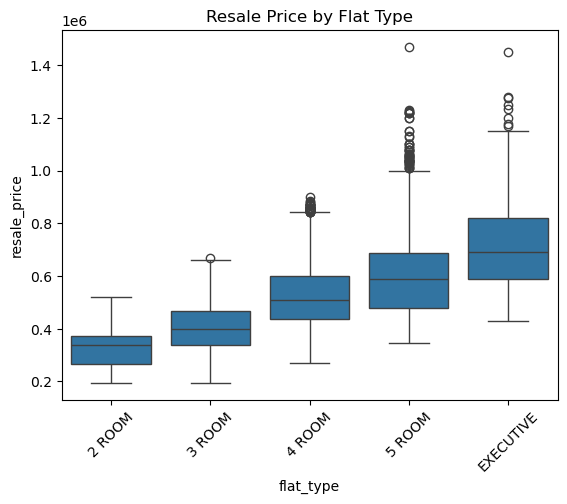

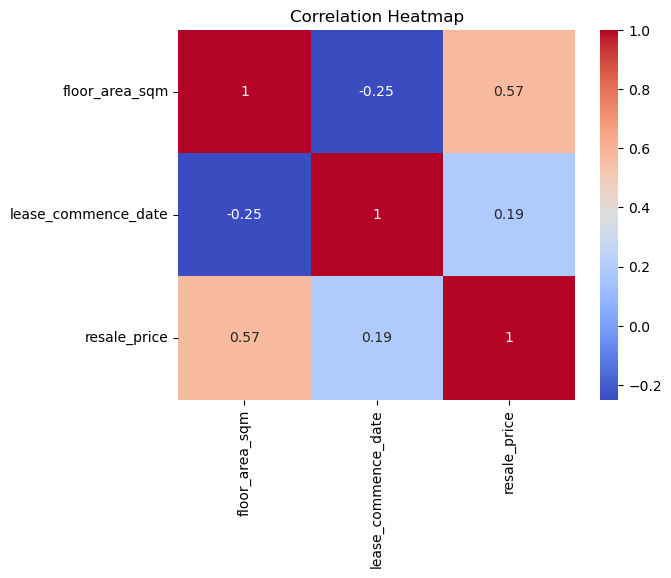

In [11]:
# Categorical feature vs target: price spread per flat type
sns.boxplot(data=df, x='flat_type', y='resale_price')
plt.title('Resale Price by Flat Type')
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap between the numeric columns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##**Relationships with resale price**

- **Correlation heatmap:** `floor_area_sqm` (0.57) and `months_since_2017` (0.57)
  are the strongest numeric drivers; `storey_mid` (0.11) is weak and
  `remaining_lease_years` (0.05) is very weak — the latter because these young
  estates all have long, similar leases with little variation.
- **Floor area vs price (scatter):** a clear positive trend — larger flats cost
  more, matching the 0.57 correlation.
- **Price by flat type (boxplot):** medians rise cleanly from 2-ROOM ($338k) to
  EXECUTIVE ($690k), so flat type is a strong, almost ordinal price driver.
- **Town** has only a modest effect (Hougang $497k → Punggol $530k, ~$33k spread).

**Implications for modelling:**
- Expect `floor_area_sqm`, `flat_type`, and `months_since_2017` to dominate
  feature importance.
- `remaining_lease_years`, `storey`, and `town` are weak predictors — good
  candidates to test dropping in the feature-selection experiments.



# 3. Data Preparation

## 3.1 Data Cleaning

In [12]:
## Clean data
# df is already filtered to our chosen towns at load time (section 2.1)
df_clean = df.copy()

# 'remaining_lease' is text like "61 years 04 months" -> convert to a numeric value in years
def parse_lease(text):
    parts = text.split()
    years = months = 0
    for i, p in enumerate(parts):
        if p.startswith('year'):
            years = int(parts[i - 1])
        elif p.startswith('month'):
            months = int(parts[i - 1])
    return years + months / 12

df_clean['remaining_lease_years'] = df_clean['remaining_lease'].apply(parse_lease)

# 'month' is text like "2017-01" -> months elapsed since the start of the data.
# Prices rose ~50% over this period, and a plain year number would lose the
# movement within each year.
sale_date = pd.to_datetime(df_clean['month'])
df_clean['months_since_2017'] = (sale_date.dt.year - 2017) * 12 + (sale_date.dt.month - 1)

# 'storey_range' is text like "10 TO 12" -> take the middle floor as a number.
# One-hot encoding would lose the fact that higher floors are higher.
df_clean['storey_mid'] = (
    df_clean['storey_range']
    .str.split(' TO ')
    .apply(lambda x: (int(x[0]) + int(x[1])) / 2)
)

# 'flat_model' has one inconsistently-cased value, plus a few categories with
# too few rows to learn from -> group those into 'Other' (6 categories, 198 rows)
df_clean['flat_model'] = df_clean['flat_model'].replace({'2-room': '2-Room'})
model_counts = df_clean['flat_model'].value_counts()
rare_models = model_counts[model_counts < 100].index
df_clean['flat_model'] = df_clean['flat_model'].where(
    ~df_clean['flat_model'].isin(rare_models), 'Other'  #SHOULD I DO THIS THO OR SHOULD I JUST DROP OR TAKE INTO CONSIDERATION IDK LEH
)

# Drop columns we won't use as features:
#  - month / remaining_lease / storey_range: replaced by the numeric versions above
#  - block: 1430 unique values, and the number alone means nothing across streets
#  - lease_commence_date: = 99 - (sale date - remaining_lease_years), so the two
#    columns above already contain it
df_clean = df_clean.drop(columns=[
    'month', 'remaining_lease', 'storey_range', 'block', 'lease_commence_date'
])

df_clean.head()


,town,flat_type,street_name,floor_area_sqm,flat_model,resale_price,remaining_lease_years,months_since_2017,storey_mid
0,HOUGANG,2 ROOM,BUANGKOK CRES,47.0,Model A,252000.0,94.333333,0,11.0
1,HOUGANG,3 ROOM,HOUGANG AVE 3,73.0,New Generation,260000.0,60.333333,0,2.0
2,HOUGANG,3 ROOM,HOUGANG AVE 8,60.0,Improved,268000.0,69.000000,0,2.0
3,HOUGANG,3 ROOM,HOUGANG AVE 3,67.0,New Generation,269000.0,60.416667,0,2.0
4,HOUGANG,3 ROOM,HOUGANG AVE 1,67.0,New Generation,270000.0,66.250000,0,2.0


## 3.2 Train-Test Split

In [13]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

#seperate target variable from features
X = df_clean.drop(columns=['resale_price'])
y = df_clean['resale_price']

# One-hot encode the categorical columns
X = pd.get_dummies(X, columns=['town', 'flat_type', 'street_name', 'flat_model'])

# Save the column list -- the app needs it to line its input up with the model
model_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (38291, 96) | Test: (9573, 96)


# 4. Modelling

### 4.2 Train Model

In [14]:
## Initialise and train model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV


models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    
}
    
for name, model in models.items():
    model.fit(X_train, y_train)
    print('trained', name)
    


trained Linear Regression
trained Decision Tree
trained Random Forest
trained Gradient Boosting


# 5. Model Evaluation

In [15]:
## Model evaluation
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error 

evaluation_results = []
for name, model in models.items():
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    print(f"Model: {name}")
    print('Train R2:', round(r2_score(y_train, train_predictions), 4))
    print('Test R2 :', round(r2_score(y_test, test_predictions), 4))
    print('Train MAE:', round(mean_absolute_error(y_train, train_predictions), 4))
    print('Test MAE :', round(mean_absolute_error(y_test, test_predictions), 4))
    print('Train RMSE:', round(root_mean_squared_error(y_train, train_predictions), 4))
    print('Test RMSE :', round(root_mean_squared_error(y_test, test_predictions), 4))
    print()
    evaluation_results.append((name, r2_score(y_test, test_predictions), mean_absolute_error(y_test, test_predictions)))

y_pred = model.predict(X_test)

table_rows = []
for name, model in models.items():
    trp = model.predict(X_train)
    tep = model.predict(X_test)
    table_rows.append({
        'Model': name,
        'Train R2': round(r2_score(y_train, trp), 4),
        'Test R2':  round(r2_score(y_test,  tep), 4),
        'Train MAE': mean_absolute_error(y_train, trp),
        'Test MAE':  mean_absolute_error(y_test,  tep),
        'Test RMSE': root_mean_squared_error(y_test, tep),
    })

results_table = pd.DataFrame(table_rows).set_index('Model')
results_table.style.format({
    'Train R2': '{:.4f}', 'Test R2': '{:.4f}',
    'Train MAE': '${:,.0f}', 'Test MAE': '${:,.0f}', 'Test RMSE': '${:,.0f}',
})

## Linear regression model is underfitting and has the worst performance among the models. It is not able 
## to capture the complex relationships in the data, leading to lower R2 and higher error metrics.
## Decision Tree has a mismatch between its train and test which is off by around 13k in MAE in decision tree.
## Random forest both MAE and RMSE are mismatched by around 11k and 16k respectively and memorising in deep trees.
## Both Random forest and Decision Tree are overfitting.
## Gradient boosting is underfitting but has the best performance overall >90 r square and similar train and test numbers.

Model: Linear Regression
Train R2: 0.8964
Test R2 : 0.8971
Train MAE: 35225.6392
Test MAE : 35107.3809
Train RMSE: 45484.2379
Test RMSE : 45606.3612

Model: Decision Tree
Train R2: 0.9991
Test R2 : 0.9415
Train MAE: 928.4875
Test MAE : 24569.5234
Train RMSE: 4177.5444
Test RMSE : 34383.3204

Model: Random Forest
Train R2: 0.9947
Test R2 : 0.9665
Train MAE: 7378.4271
Test MAE : 18836.5391
Train RMSE: 10323.1748
Test RMSE : 26018.0865

Model: Gradient Boosting
Train R2: 0.9297
Test R2 : 0.9293
Train MAE: 28324.0181
Test MAE : 28660.3829
Train RMSE: 37472.9788
Test RMSE : 37802.8597



,Train R2,Test R2,Train MAE,Test MAE,Test RMSE
Model,,,,,
Linear Regression,0.8964,0.8971,"$35,226","$35,107","$45,606"
Decision Tree,0.9991,0.9415,$928,"$24,570","$34,383"
Random Forest,0.9947,0.9665,"$7,378","$18,837","$26,018"
Gradient Boosting,0.9297,0.9293,"$28,324","$28,660","$37,803"


In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
street_cols = [c for c in X_train.columns if c.startswith('street_name_')]
##test the effect of dropping street_name features on model performance
experiments = {
    'All features (baseline)': X_train,
    'Drop street_name (73 cols)': X_train.drop(columns=street_cols),
}

for name, Xset in experiments.items():
    mae = -cross_val_score(gb, Xset, y_train, cv=5,
                           scoring='neg_mean_absolute_error').mean()
    print(f'{name:<28} CV MAE = ${mae:,.0f}  ({Xset.shape[1]} features)')


All features (baseline)      CV MAE = $28,745  (96 features)
Drop street_name (73 cols)   CV MAE = $30,225  (23 features)




Feature selection drop street_name?

`street_name` is high-cardinality (73 one-hot columns). I tested removing it,
scoring with 5-fold CV on the training set (default GB). CV MAE rose from
$28,745 to $30,225 (+$1,480), so `street_name` carries useful location signal
and is kept.



In [19]:
## Feature engineering experiment: area_per_room = floor_area_sqm / rooms
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

# rooms from flat_type; EXECUTIVE assumed = 6 (larger than 5-ROOM)  [ASSUMPTION]
rooms = df_clean['flat_type'].map(
    {'2 ROOM': 2, '3 ROOM': 3, '4 ROOM': 4, '5 ROOM': 5, 'EXECUTIVE': 6})

# rebuild X with the new feature, using the SAME split (random_state=42) so rows line up
X_fe = df_clean.drop(columns=['resale_price']).copy()
X_fe['area_per_room'] = df_clean['floor_area_sqm'] / rooms
X_fe = pd.get_dummies(X_fe, columns=['town', 'flat_type', 'street_name', 'flat_model'])
X_fe_train, X_fe_test = train_test_split(X_fe, test_size=0.2, random_state=42)

gb = GradientBoostingRegressor(random_state=42)
base = -cross_val_score(gb, X_train,    y_train, cv=5, scoring='neg_mean_absolute_error').mean()
new  = -cross_val_score(gb, X_fe_train, y_train, cv=5, scoring='neg_mean_absolute_error').mean()
print(f'Baseline (no area_per_room): ${base:,.0f}  ({X_train.shape[1]} features)')
print(f'With area_per_room:          ${new:,.0f}  ({X_fe_train.shape[1]} features)')

Baseline (no area_per_room): $28,745  (96 features)
With area_per_room:          $27,992  (97 features)


**Feature engineering — `area_per_room`**
Engineered `area_per_room = floor_area_sqm / rooms` (rooms from flat_type;
EXECUTIVE assumed = 6). 5-fold CV on the training set (default GB) improved MAE
from $28,745 to $27,992 (−$753). Default GB's shallow trees (max_depth=3) may not
fully capture the floor-area ÷ rooms ratio, so the explicit feature helps.
Not a super meaningful gain but still a gain so i kept in the final feature set.


In [20]:
## Hyperparameter tuning: Gradient Boosting via RandomizedSearchCV (final feature set, incl. area_per_room)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# max 3 values per hyperparameter (spec rule). These target GB's underfitting:
# more trees (n_estimators), deeper trees (max_depth), and a range of learning rates.
param_dist = {
    'n_estimators':  [200, 400, 600], ##add more capacity beacuse the model was underfitting,baseline was 100 so we up it to 200,400,600
    'learning_rate': [0.05, 0.1, 0.2], ## balance with n_estimators, 0.1 is the default, 0.05 is slower but more accurate, 0.2 is faster but less accurate
    'max_depth':     [3, 4, 5], ##make deeper,baseline was too shallow so cant capture interactions probably why creating area_per_room helped
}

search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10, cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1, verbose=1,
)
search.fit(X_fe_train, y_train)

best_gb = search.best_estimator_
print('Best params:', search.best_params_)
print(f'Best CV MAE : ${-search.best_score_:,.0f}')
print()

# Final evaluation on the held-out TEST set (touched once, here)
for label, Xs, ys in [('Train', X_fe_train, y_train), ('Test', X_fe_test, y_test)]:
    pred = best_gb.predict(Xs)
    print(f'{label:5} R2={r2_score(ys, pred):.4f}  '
          f'MAE=${mean_absolute_error(ys, pred):,.0f}  '
          f'RMSE=${root_mean_squared_error(ys, pred):,.0f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.1}
Best CV MAE : $17,869

Train R2=0.9782  MAE=$15,659  RMSE=$20,861
Test  R2=0.9721  MAE=$17,539  RMSE=$23,761


See how best params are top of range,like n_estimators 600 and max_depth 5 maybe we can make it even better by providing more capacity let me try that in the below cells

In [ ]:
## Refined tuning: previous winners hit the ceiling (n_estimators=600, max_depth=5),
## so search higher. Still 3 values per hyperparameter (spec rule).
param_dist_2 = {
    'n_estimators':  [600, 800, 1000],
    'max_depth':     [5, 6, 7],
    'learning_rate': [0.05, 0.1, 0.15],
}

search2 = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_2,
    n_iter=10, cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1, verbose=1,
)
search2.fit(X_fe_train, y_train)

best_gb2 = search2.best_estimator_
print('Refined best params:', search2.best_params_)
print(f'Refined best CV MAE: ${-search2.best_score_:,.0f}')
print()

for label, Xs, ys in [('Train', X_fe_train, y_train), ('Test', X_fe_test, y_test)]:
    pred = best_gb2.predict(Xs)
    print(f'{label:5} R2={r2_score(ys, pred):.4f}  '
          f'MAE=${mean_absolute_error(ys, pred):,.0f}  '
          f'RMSE=${root_mean_squared_error(ys, pred):,.0f}')

# Decision rule: adopt this only if Test MAE beats $17,539 AND the train->test gap
# stays small. If the gap widens (overfitting) or MAE stalls, keep the first model.

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Refined best params: {'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.1}
Refined best CV MAE: $17,445

Train R2=0.9843  MAE=$13,248  RMSE=$17,699
Test  R2=0.9731  MAE=$17,079  RMSE=$23,326


So after extending to search more Test MAE only improved $460 while while train test gap around doubled from 1.8k to 3.8k, the model is starting to overfit and it also took a rather long time.So I am going to stick with the first iteration as it looks like a more optimal position.

## Iterative model development


In [ ]:
## Further feature engineering / feature selection

In [27]:
import joblib

# best_gb = your final tuned model (600 / 5 / 0.1) from cell 40
joblib.dump(best_gb, 'resale_price_model.pkl')     # the trained model
joblib.dump(list(X_fe.columns), 'model_columns.pkl')  # the 97 feature columns, in order

print('Saved:', best_gb.n_estimators, 'trees |', len(X_fe.columns), 'columns')


Saved: 600 trees | 97 columns


In [28]:
## New data
import joblib

# load exactly what the app will load (this also verifies your .pkl files work)
saved_model   = joblib.load('resale_price_model.pkl')
saved_columns = joblib.load('model_columns.pkl')

# one new flat to price
new_flat = pd.DataFrame([{
    'town': 'PUNGGOL',
    'flat_type': '4 ROOM',
    'street_name': 'PUNGGOL DR',
    'floor_area_sqm': 93.0,
    'flat_model': 'Model A',
    'remaining_lease_years': 90.0,
    'months_since_2017': 108,
    'storey_mid': 11.0,
}])

# IMPORTANT: rebuild the SAME feature the model was trained on.
# area_per_room = floor_area_sqm / rooms (rooms from flat_type; EXECUTIVE = 6)
rooms = new_flat['flat_type'].map({'2 ROOM':2,'3 ROOM':3,'4 ROOM':4,'5 ROOM':5,'EXECUTIVE':6})
new_flat['area_per_room'] = new_flat['floor_area_sqm'] / rooms

# one-hot, then line the columns up with the model's training columns.
# reindex fills every column this row does not have with 0, in the right order.
new_flat = pd.get_dummies(new_flat)
new_flat = new_flat.reindex(columns=saved_columns, fill_value=0)

## Predict
print(f'Predicted resale price: ${saved_model.predict(new_flat)[0]:,.0f}')

Predicted resale price: $682,257
